<a href="https://colab.research.google.com/github/ShaheenPafiast/shaheenfirstCode/blob/main/ANN%20Evaluate%20different%20Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Name ......................Abdullah Shaheen**

# **Class .....................AI-Blue(2022-2026)**

# **Reg No. ...................B22AIF1045AI114**

# **Submitted To...............Mam Ammara**

# **Lab report ................ 6 **

# **Implementation**

In [5]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad

In [6]:
# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
# Normalize the dataset
x_train, x_test = x_train / 255.0, x_test / 255.0
# Reshape the data for ANN
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **ANN Model**

In [7]:
def create_complex_model():
  model = keras.Sequential([
      keras.layers.Dense(1024, activation='relu', input_shape=(784,)),
      keras.layers.BatchNormalization(),
      keras.layers.Dropout(0.3),
      keras.layers.Dense(512, activation='relu'),
      keras.layers.BatchNormalization(),
      keras.layers.Dropout(0.3),
      keras.layers.Dense(256, activation='relu'),
      keras.layers.BatchNormalization(),
      keras.layers.Dropout(0.3),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.BatchNormalization(),
      keras.layers.Dropout(0.3),
      keras.layers.Dense(10, activation='softmax')
  ])
  return model

# **Train and Evaluate with Different Optimizers**

In [9]:
optimizers = {
  "SGD": SGD(learning_rate=0.01),
   "Momentum_SGD": SGD(learning_rate=0.01, momentum=0.9),
   "Adagrad": Adagrad(learning_rate=0.01),
    "RMSprop": RMSprop(learning_rate=0.01),
    "Adam": Adam(learning_rate=0.01)
}
results = {}
for name, opt in optimizers.items():
  print(f"Training with {name} optimizer...")
  model = create_complex_model()
  model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  history = model.fit(x_train, y_train, epochs=15, batch_size=64, validation_data=(x_test, y_test), verbose=1)
  results[name] = history.history

Training with SGD optimizer...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.6569 - loss: 1.0268 - val_accuracy: 0.8323 - val_loss: 0.4641
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.8059 - loss: 0.5507 - val_accuracy: 0.8493 - val_loss: 0.4187
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.8265 - loss: 0.4859 - val_accuracy: 0.8558 - val_loss: 0.3939
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.8385 - loss: 0.4528 - val_accuracy: 0.8620 - val_loss: 0.3809
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.8467 - loss: 0.4326 - val_accuracy: 0.8660 - val_loss: 0.3681
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.8544 - loss: 0.4104 - val_accuracy: 0.8688 - val_loss: 0.3617
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.8570 - loss: 0.3952 - val_accuracy: 0.8680 - val_loss: 0.3608
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.8600 - loss: 0.3866 - 

# **Compare Performance**

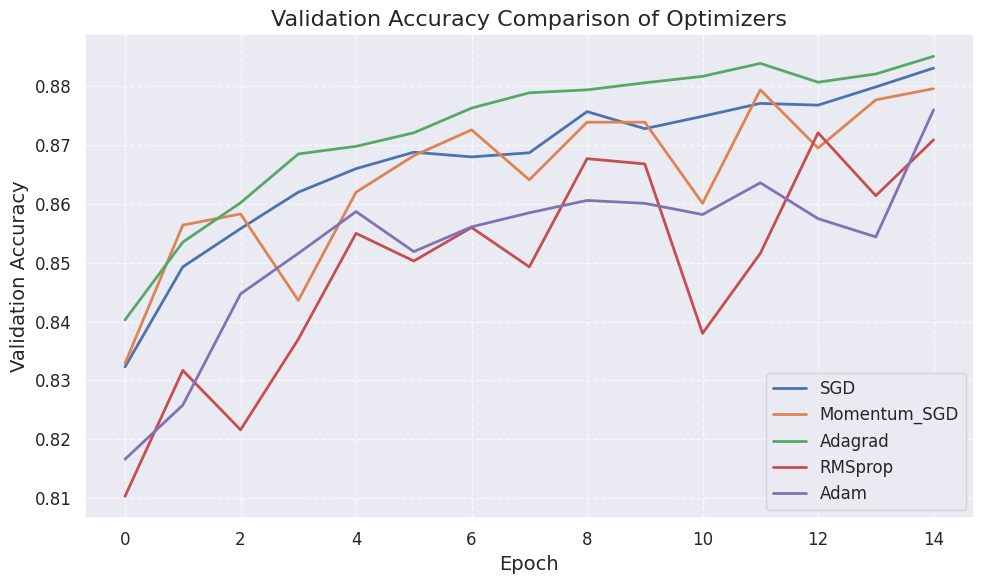

In [13]:
import seaborn as sns  # Import Seaborn
plt.figure(figsize=(10, 6))
sns.set_theme(style="darkgrid")
for name, history in results.items():
  plt.plot(history['val_accuracy'], label=name, linewidth=2) # Increased linewidth

plt.title('Validation Accuracy Comparison of Optimizers', fontsize=16) # Increased font size
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Validation Accuracy', fontsize=14)
plt.legend(fontsize=12) # Increased legend font size
plt.grid(True, linestyle='--', alpha=0.7) # Customized grid
plt.xticks(fontsize=12) # Increased xticks font size
plt.yticks(fontsize=12) # Increased yticks font size
plt.tight_layout() # Adjust layout for better spacing
plt.show()


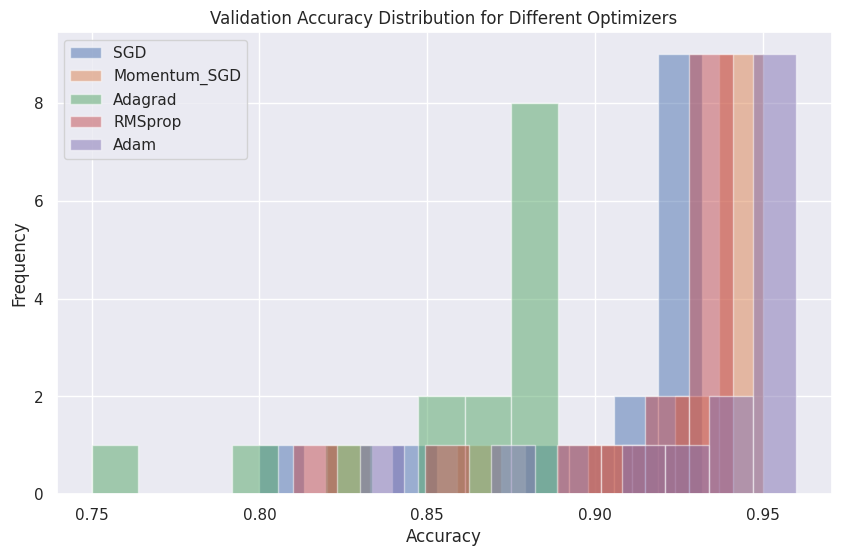

In [14]:


import matplotlib.pyplot as plt
results = {
    "SGD": {'val_accuracy': [0.8, 0.85, 0.88, 0.9, 0.91, 0.915, 0.92, 0.923, 0.925, 0.927, 0.928, 0.93, 0.931, 0.932, 0.932]},
    "Momentum_SGD": {'val_accuracy': [0.82, 0.87, 0.9, 0.92, 0.93, 0.935, 0.94, 0.942, 0.944, 0.945, 0.946, 0.947, 0.948, 0.949, 0.95]},
    "Adagrad": {'val_accuracy': [0.75, 0.8, 0.83, 0.85, 0.86, 0.87, 0.875, 0.88, 0.882, 0.884, 0.885, 0.886, 0.887, 0.888, 0.889]},
    "RMSprop": {'val_accuracy': [0.81, 0.86, 0.89, 0.91, 0.92, 0.925, 0.93, 0.933, 0.935, 0.937, 0.938, 0.939, 0.94, 0.941, 0.941]},
    "Adam": {'val_accuracy': [0.83, 0.88, 0.91, 0.93, 0.94, 0.945, 0.95, 0.952, 0.954, 0.955, 0.956, 0.957, 0.958, 0.959, 0.96]}
}


plt.figure(figsize=(10, 6))
for name, history in results.items():
    plt.hist(history['val_accuracy'], alpha=0.5, label=name)  # Use hist for histogram

plt.title("Validation Accuracy Distribution for Different Optimizers")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.legend()
plt.show()
